In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

hotels=pd.read_csv('hotel_details.csv')
hotels.head()



,Hotel Name,Place,description,Condition,Rating,Total Reviews
0,Taj Hotel & Convention Centre Agra,Agra,Travel Sustainable property,Very good,8.4,"2,509 reviews"
1,Joey's Hostel Agra,"Taj Ganj, Agra",Travel Sustainable property,Very good,8.1,"2,512 reviews"
2,Hotel Saniya Palace inn,"Taj Ganj, Agra",Travel Sustainable property,Review score,6.7,327 reviews
3,Lucky Restaurant & Guest House,"Taj Ganj, Agra",Travel Sustainable property,Good,7.1,180 reviews
4,Hotel India inn,"Taj Ganj, Agra",Travel Sustainable property,Very good,8.3,14 reviews


In [3]:
places=pd.read_csv('Top Indian Places to Visit.csv')
places.head()

,Unnamed: 0,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Weekly Off,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
0,0,Northern,Delhi,Delhi,India Gate,War Memorial,1921,0.5,4.6,0,Yes,NaN,Historical,Yes,2.60,Evening
1,1,Northern,Delhi,Delhi,Humayun's Tomb,Tomb,1572,2.0,4.5,30,Yes,NaN,Historical,Yes,0.40,Afternoon
2,2,Northern,Delhi,Delhi,Akshardham Temple,Temple,2005,5.0,4.6,60,Yes,NaN,Religious,No,0.40,Afternoon
3,3,Northern,Delhi,Delhi,Waste to Wonder Park,Theme Park,2019,2.0,4.1,50,Yes,Monday,Environmental,Yes,0.27,Evening
4,4,Northern,Delhi,Delhi,Jantar Mantar,Observatory,1724,2.0,4.2,15,Yes,NaN,Scientific,Yes,0.31,Morning


In [5]:
hotels = hotels.rename(columns={
    "Hotel Name": "hotel_name",
    "Place": "hotel_location",
    "Rating": "hotel_rating",
    "description": "description",
    "Total Reviews": "total_reviews"
})

places = places.rename(columns={
    "City": "city",
    "Name": "famous_place",
    "Google review rating": "place_rating"
})

# drop unnecessary columns
places = places[["city","famous_place","place_rating"]]


In [6]:
# extract city from hotel_location
hotels["city"] = hotels["hotel_location"].apply(lambda x: x.split(",")[-1].strip())

# merge on city
merged = pd.merge(hotels, places, on="city", how="inner")

print(merged.head())


                           hotel_name  hotel_location  \
0  Taj Hotel & Convention Centre Agra            Agra   
1  Taj Hotel & Convention Centre Agra            Agra   
2                  Joey's Hostel Agra  Taj Ganj, Agra   
3                  Joey's Hostel Agra  Taj Ganj, Agra   
4             Hotel Saniya Palace inn  Taj Ganj, Agra   

                   description     Condition  hotel_rating  total_reviews  \
0  Travel Sustainable property     Very good           8.4  2,509 reviews   
1  Travel Sustainable property     Very good           8.4  2,509 reviews   
2  Travel Sustainable property     Very good           8.1  2,512 reviews   
3  Travel Sustainable property     Very good           8.1  2,512 reviews   
4  Travel Sustainable property  Review score           6.7    327 reviews   

   city famous_place  place_rating  
0  Agra    Taj Mahal           4.6  
1  Agra    Agra Fort           4.5  
2  Agra    Taj Mahal           4.6  
3  Agra    Agra Fort           4.5  
4  Agra  

In [8]:
merged.shape

(37215, 9)

In [9]:
merged.to_csv("final_hotels.csv", index=False)

In [10]:
merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37215 entries, 0 to 37214
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hotel_name      37215 non-null  object 
 1   hotel_location  37215 non-null  object 
 2   description     37215 non-null  object 
 3   Condition       32754 non-null  object 
 4   hotel_rating    32732 non-null  float64
 5   total_reviews   32754 non-null  object 
 6   city            37215 non-null  object 
 7   famous_place    37215 non-null  object 
 8   place_rating    37215 non-null  float64
dtypes: float64(2), object(7)
memory usage: 2.6+ MB


,hotel_rating,place_rating
count,32732.000000,37215.000000
mean,6.739429,4.459936
std,2.010667,0.186966
min,1.000000,3.800000
25%,5.800000,4.400000
50%,7.200000,4.400000
75%,8.100000,4.600000
max,10.000000,4.900000


In [11]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37215 entries, 0 to 37214
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hotel_name      37215 non-null  object 
 1   hotel_location  37215 non-null  object 
 2   description     37215 non-null  object 
 3   Condition       32754 non-null  object 
 4   hotel_rating    32732 non-null  float64
 5   total_reviews   32754 non-null  object 
 6   city            37215 non-null  object 
 7   famous_place    37215 non-null  object 
 8   place_rating    37215 non-null  float64
dtypes: float64(2), object(7)
memory usage: 2.6+ MB


In [12]:
merged.columns

Index(['hotel_name', 'hotel_location', 'description', 'Condition',
       'hotel_rating', 'total_reviews', 'city', 'famous_place',
       'place_rating'],
      dtype='object')

In [13]:
merged.duplicated().sum()

# duplicates by hotel
merged["hotel_name"].duplicated().sum()

np.int64(31960)

In [14]:
merged.isnull().sum()

,0
hotel_name,0
hotel_location,0
description,0
Condition,4461
hotel_rating,4483
total_reviews,4461
city,0
famous_place,0
place_rating,0


In [16]:
print("Unique hotels:", merged["hotel_name"].nunique())
print("Cities:", merged["city"].nunique())
print("Tourist places:", merged["famous_place"].nunique())

Unique hotels: 5255
Cities: 21
Tourist places: 73


In [17]:
merged.sort_values(by="hotel_rating", ascending=False).head(10)


,hotel_name,hotel_location,description,Condition,hotel_rating,total_reviews,city,famous_place,place_rating
6971,The Ocea International Hotel,"Bangalore Shopping Area, Bangalore","Situated in Bangalore, 80 metres from Brigade ...",Exceptional,10.0,1 review,Bangalore,Lalbagh Botanical Garden,4.4
6972,The Ocea International Hotel,"Bangalore Shopping Area, Bangalore","Situated in Bangalore, 80 metres from Brigade ...",Exceptional,10.0,1 review,Bangalore,Cubbon Park,4.4
6973,The Ocea International Hotel,"Bangalore Shopping Area, Bangalore","Situated in Bangalore, 80 metres from Brigade ...",Exceptional,10.0,1 review,Bangalore,Vidhana Soudha,4.6
6974,The Ocea International Hotel,"Bangalore Shopping Area, Bangalore","Situated in Bangalore, 80 metres from Brigade ...",Exceptional,10.0,1 review,Bangalore,ISKCON Temple Bangalore,4.6
17957,Elegant Residences,"Ballygunge, Kolkata","Elegant Residences, a property with a terrace,...",Exceptional,10.0,1 review,Kolkata,Indian Museum,4.6
17958,Elegant Residences,"Ballygunge, Kolkata","Elegant Residences, a property with a terrace,...",Exceptional,10.0,1 review,Kolkata,Dakshineswar Kali Temple,4.7
17959,Elegant Residences,"Ballygunge, Kolkata","Elegant Residences, a property with a terrace,...",Exceptional,10.0,1 review,Kolkata,Kalighat Kali Temple,4.4
17960,Elegant Residences,"Ballygunge, Kolkata","Elegant Residences, a property with a terrace,...",Exceptional,10.0,1 review,Kolkata,Eden Gardens,4.1
17961,Elegant Residences,"Ballygunge, Kolkata","Elegant Residences, a property with a terrace,...",Exceptional,10.0,1 review,Kolkata,Alipore Zoological Gardens,4.3
17962,Elegant Residences,"Ballygunge, Kolkata","Elegant Residences, a property with a terrace,...",Exceptional,10.0,1 review,Kolkata,Science City Kolkata,4.4


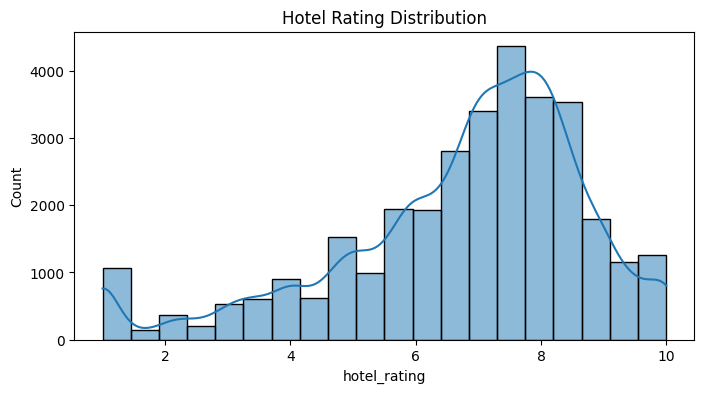

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(merged["hotel_rating"], bins=20, kde=True)
plt.title("Hotel Rating Distribution")
plt.show()

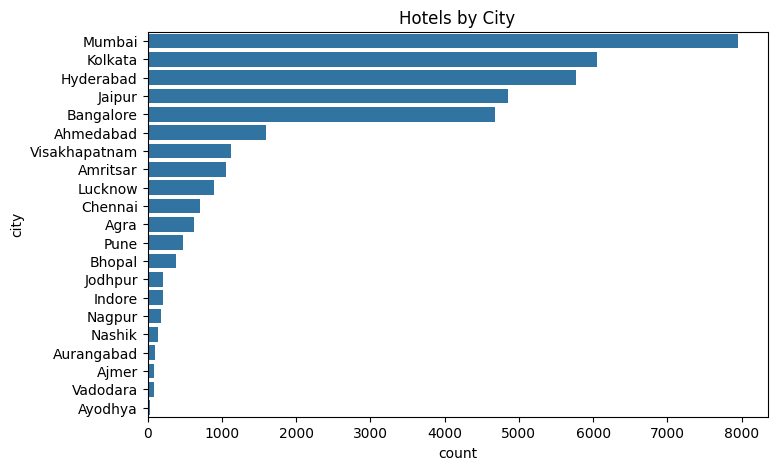

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(y="city", data=merged, order=merged["city"].value_counts().index)
plt.title("Hotels by City")
plt.show()


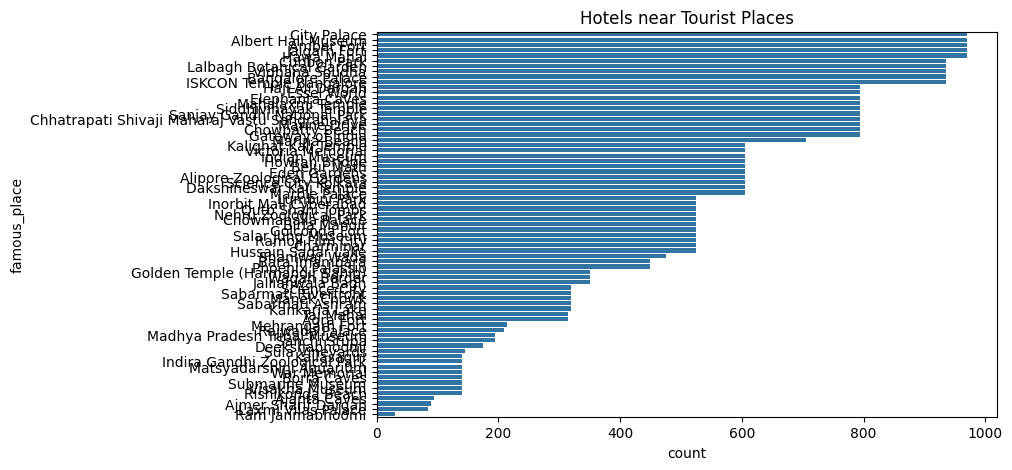

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(y="famous_place", data=merged,
              order=merged["famous_place"].value_counts().index)
plt.title("Hotels near Tourist Places")
plt.show()


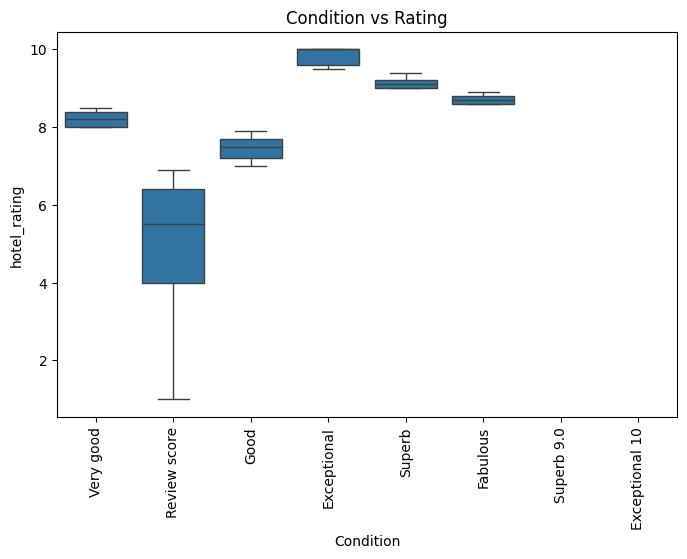

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Condition", y="hotel_rating", data=merged)
plt.xticks(rotation=90)
plt.title("Condition vs Rating")
plt.show()


In [24]:
def sentiment_from_rating(rating):
    if rating >= 8:
        return "Highly Recommended"
    elif rating >= 7:
        return "Recommended"
    elif rating >= 6:
        return "Average"
    else:
        return "Not Recommended"

merged["sentiment"] = merged["hotel_rating"].apply(sentiment_from_rating)


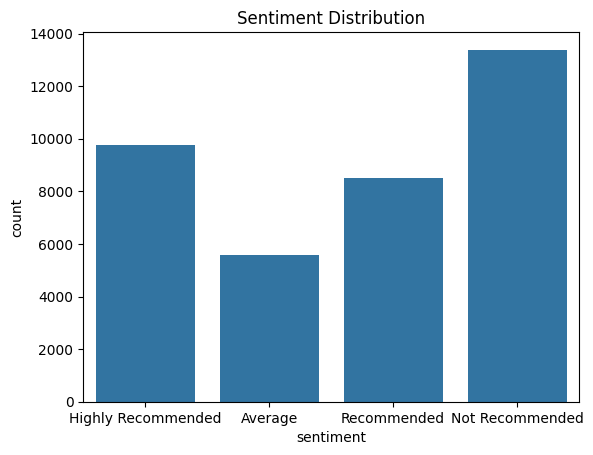

In [27]:
sns.countplot(x="sentiment", data=merged)
plt.title("Sentiment Distribution")
plt.show()
